# Tutorial 3: $\mathcal U$ and $\mathcal F$ from the graph, at one, two and three loops

**What you will learn**
1. how to enter a Feynman diagram as a graph
2. spanning trees and 2-forests, with pictures
3. the Symanzik polynomials $\mathcal U$ and $\mathcal F$ read off from them (the rules of Section 14 of the note)
4. three independent checks of every polynomial
5. two- and three-loop graphs, and how to use $\mathcal U$ and $\mathcal F$ to get a number

**The rules.** Give line $e$ the Feynman parameter $x_e$.
- $\mathcal U$ = sum over spanning trees of the product of the $x_e$ of the *removed* lines.
- $\mathcal F_0$ = sum over 2-forests of (product of the removed $x_e$) $\times P^2$, where $P$ is the external momentum flowing into one of the two trees.
- $\mathcal F = \mathcal F_0 + \mathcal U\sum_e x_e m_e^2$ (Euclidean). In Minkowski space $\mathcal F = -\mathcal F_0 + \mathcal U\sum_e x_e m_e^2$.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))     # use the feynsage of this repository (not needed after ./install.sh)
from feynsage import *
%display latex
from feynsage.plotting import set_theme, draw_panels
import time
set_theme()

## Step 1: a graph from strings

`graph(edges, legs, kin)`.
- `edges`: lines `"A-B"` between vertices, `"A-B:m"` for a massive line. The order of the lines is the numbering $x_1, x_2, \dots$
- `legs`: the momentum *entering* at each vertex (they must add up to zero)
- `kin`: the scalar products. `euclidean=True` for Euclidean signs.

The bubble with two different masses:

lines N = 2   vertices V = 2   loops L = N - V + 1 = 1


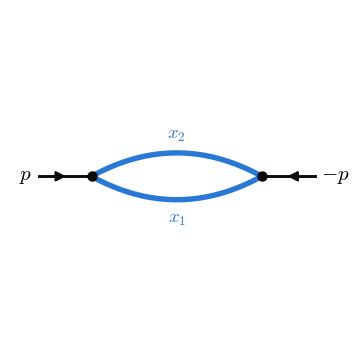

In [2]:
bub = graph("A-B:ma, A-B:mb", {"A": "p", "B": "-p"}, kin={"p^2": "pp"}, euclidean=True)
print("lines N =", bub.N, "  vertices V =", bub.V, "  loops L = N - V + 1 =", bub.L)
bub.plot();

## Step 2: spanning trees

A spanning tree touches every vertex and has no loop. Here we must remove $L = 1$ line. `spanning_trees()` lists the *removed* lines (numbered from 0).

In [3]:
def xs(rem):
    return "$" + "".join("x_{%d}" % (i + 1) for i in rem) + "$"

trees = bub.spanning_trees()
print(trees)
draw_panels(bub, trees, titles=["remove " + xs(r) for r in trees], momenta=False);
bub.U()

[(0,), (1,)]


x1 + x2

## Step 3: 2-forests

Remove one more line, $L + 1 = 2$ in all. The graph falls into two trees. `two_forests()` gives the removed lines and the vertices of one tree.

In [4]:
forests = bub.two_forests()
print(forests)
draw_panels(bub, [r for r, comp in forests], titles=["remove " + xs(r) for r, comp in forests], momenta=False);

[((0, 1), ['A'])]


The momentum $p$ enters at A, so the term is $x_1 x_2\,p^2$. With the masses added:

In [5]:
bub.F()

ma^2*x1^2 + (ma^2 + mb^2 + pp)*x1*x2 + mb^2*x2^2

This is $\mathcal F = x_1 x_2 p^2 + (x_1 + x_2)(m_a^2 x_1 + m_b^2 x_2)$ of the note.

## Step 4: three independent checks

The same polynomials can be found in two more ways:
- `U_kirchhoff()`: the matrix-tree theorem, a determinant of the graph Laplacian. No trees are listed.
- `family()` routes loop momenta through the graph. `IntegralFamily(...).UF()` then finds $\mathcal U = \det M$ and $\mathcal F$ by completing the square in the momenta. No graph theory at all.

The function below runs all three and says whether they agree.

In [6]:
def three_ways(g, name="g"):
    t0 = time.time()
    U, F = g.U(), g.F()
    t1 = time.time()
    props, loops = g.family()
    Um, Fm = IntegralFamily(name, loops, g.kin, props).UF()
    same = g.U_kirchhoff() == U and g.R(str(Um)) == U and g.R(str(Fm)) == F
    print("L = %d, %d lines, %d spanning trees, %d 2-forests, trees and forests took %.3f s"
          % (g.L, g.N, len(g.spanning_trees()), len(g.two_forests()), t1 - t0))
    print("trees = Kirchhoff = matrix method:", same)
    return U, F

three_ways(bub, "bub")

L = 1, 2 lines, 2 spanning trees, 1 2-forests, trees and forests took 0.000 s
trees = Kirchhoff = matrix method: True


(x1 + x2, ma^2*x1^2 + (ma^2 + mb^2 + pp)*x1*x2 + mb^2*x2^2)

## Step 5: two loops

`diagram()` lists ready-made graphs. `diagram("vertex2")` is the planar two-loop vertex of the note (Section 21.7), with the lines numbered as in the note's picture.

In [7]:
diagram()

tadpole      one massive line from a vertex back to itself
bubble       massless bubble, p^2 = s
bubble_mass  equal-mass bubble
triangle     massless triangle with three off-shell legs
box          massless box, on-shell legs, s and t
sunset       two-loop sunset, three equal masses
kite         two-loop massless kite
phi4_two     two-loop phi^4 diagram of the notes
vertex2      planar two-loop vertex, on-shell massless legs (lines x1..x6 as in the notes)
banana3      three-loop banana, four equal masses
ladder3      three-loop massless ladder propagator
triplebox    three-loop massless planar triple box, on-shell legs, s and t


In [8]:
v2 = diagram("vertex2")
v2.plot(figsize=(3.2, 3.2));
U, F = three_ways(v2, "vertex2")
show(SR(str(U)).factor())
show(SR(str(F)).factor())

L = 2, 6 lines, 11 spanning trees, 19 2-forests, trees and forests took 0.001 s
trees = Kirchhoff = matrix method: True


x1*x2 + x1*x3 + x2*x4 + x3*x4 + x2*x5 + x3*x5 + x1*x6 + x2*x6 + x3*x6 + x4*x6 + x5*x6

-(x1*x2*x3 + x1*x2*x4 + x1*x3*x4 + x2*x3*x4 + x2*x3*x5 + x1*x3*x6 + x2*x3*x6 + x1*x4*x6 + x2*x4*x6)*q2

Compare with the note:
$$\mathcal U = (x_2 + x_3)(x_1 + x_4 + x_5) + (x_1 + \dots + x_5)\,x_6, \qquad \mathcal F = -q^2\big[x_1x_3x_4 + x_1x_2(x_3 + x_4) + x_2x_3(x_4 + x_5) + (x_1 + x_2)(x_3 + x_4)x_6\big]$$
(Minkowski, $q^2 = 2p_1\cdot p_2$, written `q2`). Let Sage do the comparison:

In [9]:
R = v2.R
x1, x2, x3, x4, x5, x6 = R.gens()
q2 = R.base_ring()('q2')
U_note = (x2 + x3)*(x1 + x4 + x5) + (x1 + x2 + x3 + x4 + x5)*x6
F_note = -q2*(x1*x3*x4 + x1*x2*(x3 + x4) + x2*x3*(x4 + x5) + (x1 + x2)*(x3 + x4)*x6)
U == U_note, F == F_note

(True, True)

## Step 6: three loops

Nothing changes at three loops. The number of trees and forests grows, but for diagrams of this size it is still a fraction of a second.

In [10]:
for name in ["banana3", "ladder3", "triplebox"]:
    print("==", name)
    three_ways(diagram(name), name)

== banana3
L = 3, 4 lines, 4 spanning trees, 1 2-forests, trees and forests took 0.000 s
trees = Kirchhoff = matrix method: True
== ladder3
L = 3, 8 lines, 30 spanning trees, 59 2-forests, trees and forests took 0.003 s
trees = Kirchhoff = matrix method: True
== triplebox
L = 3, 10 lines, 56 spanning trees, 163 2-forests, trees and forests took 0.010 s
trees = Kirchhoff = matrix method: True


In [11]:
tb = diagram("triplebox")
tb.plot();
print("U has %d terms and F has %d terms" % (len(tb.U().monomials()), len(tb.F().monomials())))

U has 56 terms and F has 65 terms


## Step 7: from $\mathcal U$ and $\mathcal F$ to a number

With all powers 1, $N$ lines and $L$ loops, the Feynman-parameter formula of the note is
$$I = \Gamma\!\left(N - \tfrac{LD}{2}\right)\int_{x_i \ge 0} d^Nx\;\delta\Big(1 - \sum x_i\Big)\,\frac{\mathcal U^{\,N - (L+1)D/2}}{\mathcal F^{\,N - LD/2}} .$$
Take the massless one-loop bubble at $p^2 = 1$ and $D = 3.3$ (any $D$ where it converges). On the delta function $x_2 = 1 - x_1$, so it is a one-dimensional integral. Compare with the closed result `bubble_massless(1, 1, 1)` of `feynsage.oneloop`.

In [12]:
from feynsage.oneloop import bubble_massless, D
g0 = graph("A-B, A-B", {"A": "p", "B": "-p"}, kin={"p^2": 1}, euclidean=True)
U0, F0 = g0.U(), g0.F()
print("U =", U0, "   F =", F0)
Dv, N, L = 3.3, 2, 1
x = var('x')
u = SR(str(U0)).subs(x1=x, x2=1 - x)
f = SR(str(F0)).subs(x1=x, x2=1 - x)
integrand = u^(N - (L + 1)*Dv/2) / f^(N - L*Dv/2)
num = gamma(N - L*Dv/2) * numerical_integral(integrand, 0, 1)[0]
print("from U and F:  ", num)
print("closed form:   ", bubble_massless(1, 1, 1).subs(D=Dv).n())

U = x1 + x2    F = x1*x2
from U and F:   5.44044255456555
closed form:    5.44044257084738


They agree to eight digits. The integrand grows like $x^{-0.35}$ at both ends, which limits the numerical integration, not the formula.

## Exercises

**1.** Enter the two-loop sunset with three equal masses (three lines between the same two vertices). How many spanning trees does it have? Write down $\mathcal U$ and check it against the note's $x_1x_2 + x_1x_3 + x_2x_3$.
<details><summary>Show a solution</summary>

```python
sun = graph("A-B:m, A-B:m, A-B:m", {"A": "p", "B": "-p"}, kin={"p^2": "s"})
print(len(sun.spanning_trees()), sun.U())
sun.F()
```
</details>

**2.** The four-loop banana has five lines between two vertices. Predict the number of spanning trees (remove 4 of the 5 lines) and check.
<details><summary>Show a solution</summary>

```python
b4 = graph("A-B, A-B, A-B, A-B, A-B", {"A": "p", "B": "-p"}, kin={"p^2": "s"})
print(b4.L, len(b4.spanning_trees()))     # 5 choose 4 = 5
three_ways(b4, "banana4")
```
</details>

**3.** In the two-loop vertex, which 2-forests do *not* contribute to $\mathcal F$ and why? (Hint: print `two_forests()` and look at which vertices are in each tree.)
<details><summary>Show a solution</summary>

```python
for rem, comp in v2.two_forests():
    print([i + 1 for i in rem], sorted(comp))
# a forest whose small tree holds only C1 (or only C2) carries p1^2 = 0 (or p2^2 = 0)
```
</details>